# **Descarga de licitaciones en plazo de PSCP Catalunya**

Notebook editado el 04/09/2026

---
## **Set-up**
---

Instalación e importación de librerías:

In [1]:
!pip install pandas sodapy sentence-transformers supabase

In [2]:
from datetime import datetime, date
from google.colab import userdata
import os
import time
from sodapy import Socrata
import pandas as pd
from sentence_transformers import SentenceTransformer
from supabase import create_client, Client

Configuración de la Base de Datos:

In [3]:
SUPABASE_URL = userdata.get("SUPABASE_URL")
SUPABASE_KEY = userdata.get("SUPABASE_KEY")
supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)

Carga del modelo de embbedings:

In [4]:
print("Cargando modelo de IA (multilingual-e5-small)...")
encoder = SentenceTransformer("intfloat/multilingual-e5-small", device="cpu")

Cargando modelo de IA (multilingual-e5-small)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

---
## **Funciones**
---

Añade Cataluña al lugar de ejecución detectado. Al tratarse de la PSCP, si el lugar de ejecución está vacío, se añade Cataluña por defecto. En otro caso, lo adjunta al final si el lugar original no la menciona. Esto se hace para que, al filtrar por Cataluña, también salgan todas las licitaciones del PSCP y no se pierdan por estar etiquetadas con lugares específicos.

In [5]:
def procesar_lugar(lugar_raw):
    """Añade Cataluña al lugar de ejecución detectado."""
    lugar_limpio = str(lugar_raw).strip() if lugar_raw else "No especificado"
    if lugar_limpio == "No especificado" or not lugar_limpio:
        return "Cataluña"

    # Evitar duplicar si ya incluye Cataluña
    if "cataluña" not in lugar_limpio.lower() and "catalunya" not in lugar_limpio.lower():
        return f"{lugar_limpio}, Cataluña"
    return lugar_limpio

---
## **Extracción y sincronización PSCP Cataluña**
---

* Dominio oficial de datos abiertos de la Generalitat de Cataluña: **analisi.transparenciacatalunya.cat**
* "ybgg-dgi6" es el identificador del dataset **"Contractació pública a Catalunya: publicacions a la Plataforma de serveis de contractació pública (PSCP)"**
* El dataset se suele actualizar dos veces al día (2 am y 9 am).
* La API tiene un límite de 1000 filas. Recalcan la necesidad de paginación.

Siendo las siguientes las distintas fases de publicación, filtramos por solo aquellas que estén abiertas para presentarse (por ende, "Anunci de licitació).

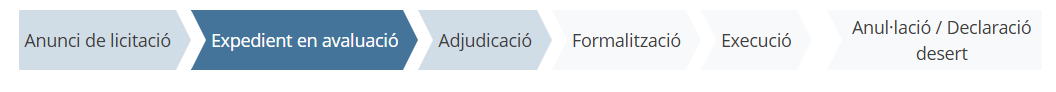

No inserta si ya estaba en la Base de Datos, al igual que no inserta las cerradas o cuya fecha de cierre es anterior a hoy.

In [6]:
def sincronizar_licitaciones_pscp():
    hoy = datetime.now().date()
    dataset_id = "ybgg-dgi6"
    client = Socrata("analisi.transparenciacatalunya.cat", None)

    # Rango de fechas (del 1 al 2 de septiembre de 2026)
    fecha_inicio = "2026-09-01T00:00:00"
    fecha_fin = "2026-09-05T00:00:00"

    query = f"data_publicacio_anunci >= '{fecha_inicio}' AND data_publicacio_anunci < '{fecha_fin}' AND fase_publicacio = 'Anunci de licitació'"

    print("Consultando la API de la PSCP...")
    chunk_size = 1000
    offset = 0
    results = []

    while True:
        try:
            chunk = client.get(
                dataset_id,
                where=query,
                order="data_publicacio_anunci DESC",
                limit=chunk_size,
                offset=offset
            )
            if not chunk:
                break
            results.extend(chunk)
            print(f"Descargados {len(chunk)} registros (Offset: {offset}). Total acumulado: {len(results)}")
            if len(chunk) < chunk_size:
                break
            offset += chunk_size
        except Exception as e:
            print(f"Error conectando con la API de PSCP: {e}")
            break

    print(f"\nTotal registros obtenidos de la API PSCP: {len(results)}\n")
    if not results:
        print("No se obtuvieron registros para las fechas indicadas.")
        return

    # Cargar registros existentes en Supabase para evitar duplicados
    try:
        existentes_resp = supabase.table("licitaciones").select("enlace, titulo, organo").execute()
        # The 'enlace' in existing_resp.data is a string, so we create a set of strings
        mapa_enlaces = {item["enlace"] for item in existentes_resp.data if "enlace" in item}

        registros_existentes = set()
        for item in existentes_resp.data:
            t = str(item.get("titulo", "")).strip().lower()
            o = str(item.get("organo", "")).strip().lower()
            if t or o:
                registros_existentes.add((t, o))

        print(f"Registros cargados desde Supabase para validación: {len(registros_existentes)}")
    except Exception as e:
        print(f"Error conectando con Supabase: {e}")
        return

    licitaciones_validas = []
    filtrados_caducados = 0
    filtrados_duplicados = 0
    enlaces_ya_procesados_en_sesion = set() # Track links already added in this run

    for aviso in results:
        enlace_raw = aviso.get("enllac_publicacio")
        # Extract the URL string from the dictionary
        enlace = enlace_raw.get('url') if isinstance(enlace_raw, dict) and 'url' in enlace_raw else str(enlace_raw)

        if not enlace:
            continue

        # Extracción directa sin funciones complejas de limpieza de texto
        titulo_str = str(aviso.get("denominacio", "Sin título")).strip()
        organo_str = str(aviso.get("nom_organ", "No especificado")).strip()

        # Validar fecha de cierre / caducidad
        fecha_fin_str = "No especificada"
        fecha_cierre_raw = aviso.get("termini_presentacio_ofertes")
        if fecha_cierre_raw:
            fecha_fin_str = fecha_cierre_raw[:10]
            try:
                cierre_date = datetime.strptime(fecha_fin_str, "%Y-%m-%d").date()
                if cierre_date < hoy:
                    filtrados_caducados += 1
                    continue
            except ValueError:
                pass

        fecha_pub = aviso.get("data_publicacio_anunci", "")[:10]

        importe_val = aviso.get("pressupost_licitacio_sense_iva_expedient") or aviso.get("pressupost_licitacio_sense_1") or 0.0
        try:
            importe = float(importe_val)
        except (ValueError, TypeError):
            importe = 0.0

        cpv_raw = aviso.get("codi_cpv", "No especificado")
        if cpv_raw and cpv_raw != "No especificado":
            cpv = ", ".join([c.strip() for c in str(cpv_raw).split("||") if c.strip()])
        else:
            cpv = "No especificado"
        lugar_bruto = aviso.get("lloc_execucio", "No especificado")
        lugar_ejecucion = procesar_lugar(lugar_bruto)

        # Comprobación de duplicados por enlace (ya en Supabase o ya procesado en esta sesión)
        # o por combinación (título, órgano) si no se pudo determinar el enlace
        clave_duplicado = (titulo_str.lower(), organo_str.lower())
        if enlace in mapa_enlaces or enlace in enlaces_ya_procesados_en_sesion or clave_duplicado in registros_existentes:
            filtrados_duplicados += 1
            continue

        # Add link to the set of processed links for this session
        enlaces_ya_procesados_en_sesion.add(enlace)

        # Generar texto completo y embedding
        texto_completo = f"passage: Título: {titulo_str}. Órgano: {organo_str}. CPV: {cpv}. Lugar: {lugar_ejecucion}. Importe: {importe} EUR."
        embedding = encoder.encode(texto_completo).tolist()

        elemento = {
            "titulo": titulo_str,
            "organo": organo_str,
            "fecha": fecha_pub,
            "importe": importe,
            "enlace": enlace,
            "texto_completo": texto_completo,
            "embedding": embedding,
            "fecha_fin": fecha_fin_str,
            "lugar_ejecucion": lugar_ejecucion,
            "cpv": cpv,
            "es_novedad": False,
            "es_actualizada": False,
            "fuente": "PSCP Catalunya"
        }

        licitaciones_validas.append(elemento)

    print(f"\n--- ESTADÍSTICAS PSCP ---")
    print(f"Descartados por fecha caducada: {filtrados_caducados}")
    print(f"Duplicados evitados (Supabase/sesión actual): {filtrados_duplicados}")
    print(f"Licitaciones válidas listas para insertar: {len(licitaciones_validas)}\n")

    # Inserción en Supabase por lotes
    if licitaciones_validas:
        print("Subiendo licitaciones de PSCP Catalunya a Supabase...")
        tamano_lote = 15
        max_intentos = 3

        for i in range(0, len(licitaciones_validas), tamano_lote):
            lote = licitaciones_validas[i:i + tamano_lote]
            num_lote = i // tamano_lote + 1
            exito = False

            for intento in range(1, max_intentos + 1):
                try:
                    supabase.table("licitaciones").upsert(lote, on_conflict="enlace").execute()
                    print(f"  -> Lote PSCP {num_lote} procesado con éxito ({len(lote)} registros).")
                    exito = True
                    break
                except Exception as e:
                    print(f"Intento {intento}/{max_intentos} fallido para lote PSCP {num_lote}: {e}")
                    if intento < max_intentos:
                        time.sleep(2 * intento)
                    else:
                        print(f"Error definitivo al subir lote PSCP {num_lote}.")

        print("¡Sincronización de PSCP Catalunya completada con éxito!")
    else:
        print("No hay nuevas licitaciones de PSCP para insertar.")

if __name__ == "__main__":
    sincronizar_licitaciones_pscp()

Consultando la API de la PSCP...
Descargados 552 registros (Offset: 0). Total acumulado: 552

Total registros obtenidos de la API PSCP: 552

Registros cargados desde Supabase para validación: 6757

--- ESTADÍSTICAS PSCP ---
Descartados por fecha caducada: 32
Duplicados evitados (Supabase/sesión actual): 520
Licitaciones válidas listas para insertar: 0

No hay nuevas licitaciones de PSCP para insertar.
